### 1. Import Library
Mengimpor seluruh library yang dipakai di notebook ini: OpenCV & scikit-image untuk pengolahan citra, NumPy/Pandas untuk manipulasi data, dan scikit-learn untuk preprocessing, training, cross validation, serta evaluasi model SVM.

In [3]:
import os
import cv2
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

### 2. Memuat Dataset Gambar
Fungsi `load_dataset` membaca dan me-resize seluruh gambar biji gandum di setiap folder kelas (`healthy_kernel`, `green_immature`, `shrunken_broken`, `insect_chewed`) menjadi ukuran 225x225 piksel.

In [4]:
base_dir = '.'

def load_dataset(folder, size=(225, 225)):
    images = []
    for files in os.listdir(folder):
        img_path = os.path.join(folder, files)
        img = cv2.imread(img_path)
        if img is not None:
            img_resized = cv2.resize(img, size)
            images.append((files, img_resized))
    return images


image_datasets = {
    'healthy_kernel': load_dataset(os.path.join(base_dir, 'healthy_kernel')),
    'green_immature': load_dataset(os.path.join(base_dir, 'green_immature')),
    'shrunken_broken': load_dataset(os.path.join(base_dir, 'shrunken_broken')),
    'insect_chewed': load_dataset(os.path.join(base_dir, 'insect_chewed'))
}

for label, images in image_datasets.items():
    print(f'{label}: {len(images)} images loaded.')

healthy_kernel: 500 images loaded.
green_immature: 500 images loaded.
shrunken_broken: 500 images loaded.
insect_chewed: 500 images loaded.


### 3. Ekstraksi Fitur Tekstur (GLCM)
Menghitung fitur tekstur Gray-Level Co-occurrence Matrix (contrast, dissimilarity, homogeneity, energy, correlation) dari citra grayscale.

In [5]:
def extract_glcm_features(image):
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    glcm = graycomatrix(gray_image, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast')
    dissimilarity = graycoprops(glcm, 'dissimilarity')
    homogeneity = graycoprops(glcm, 'homogeneity')
    energy = graycoprops(glcm, 'energy')
    correlation = graycoprops(glcm, 'correlation')

    return [
        contrast[0, 0],
        dissimilarity[0, 0],
        homogeneity[0, 0],
        energy[0, 0],
        correlation[0, 0],
    ]

### 4. Ekstraksi Fitur Warna — Channel Green (RGB)
Mengambil rata-rata dan standar deviasi intensitas channel hijau (G) dari citra RGB.

In [6]:
def extract_rgb_features(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    green_channel = image[:, :, 1]
    mean_green = np.mean(green_channel)
    std_green = np.std(green_channel)
    return [mean_green, std_green]

### 5. Ekstraksi Fitur Warna — Channel Value (HSV)
Mengambil rata-rata dan standar deviasi channel Value (V) dari citra HSV.

In [7]:
def extract_hsv_features(image):
    image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    v_channel = image[:, :, 2]
    mean_v = np.mean(v_channel)
    std_v = np.std(v_channel)
    return [mean_v, std_v]

### 6. Gabungan Seluruh Fitur
Menggabungkan fitur GLCM, RGB, dan HSV menjadi satu vektor fitur per gambar.

In [8]:
def extract_all_features(image):
    glcm_features = extract_glcm_features(image)
    rgb_features = extract_rgb_features(image)
    hsv_features = extract_hsv_features(image)
    return glcm_features + rgb_features + hsv_features

print('Feature extraction functions ready!')

Feature extraction functions ready!


### 7. Ekstraksi Fitur untuk Seluruh Dataset
Menerapkan `extract_all_features` ke semua gambar di tiap kelas dan mengumpulkan hasilnya beserta labelnya masing-masing.

In [9]:
features, labels = [], []

for label, images in image_datasets.items():
    print(f"Processing {label}...")
    for i, (filename, image_data) in enumerate(images):
        try:
            extracted_features = extract_all_features(image_data)
            features.append(extracted_features)
            labels.append(label)

            if (i + 1) % 100 == 0:
                print(f"  Processed {i + 1}/{len(images)} images")

        except Exception as e:
            print(f"  Error processing image {filename}: {e}")
            continue

print(f'\nExtracted features for {len(features)} images.')

Processing healthy_kernel...
  Processed 100/500 images
  Processed 200/500 images
  Processed 300/500 images
  Processed 400/500 images
  Processed 500/500 images
Processing green_immature...
  Processed 100/500 images
  Processed 200/500 images
  Processed 300/500 images
  Processed 400/500 images
  Processed 500/500 images
Processing shrunken_broken...
  Processed 100/500 images
  Processed 200/500 images
  Processed 300/500 images
  Processed 400/500 images
  Processed 500/500 images
Processing insect_chewed...
  Processed 100/500 images
  Processed 200/500 images
  Processed 300/500 images
  Processed 400/500 images
  Processed 500/500 images

Extracted features for 2000 images.


### 8. Membentuk DataFrame
Menyusun fitur dan label yang telah diekstrak ke dalam `pandas.DataFrame` agar mudah dianalisis.

In [10]:
glcm_columns = [
    'contrast_0',
    'dissimilarity_0',
    'homogeneity_0',
    'energy_0',
    'correlation_0',
]

rgb_columns = ['mean_g', 'std_g']

hsv_columns = ['mean_v', 'std_v']

columns = glcm_columns + rgb_columns + hsv_columns

df = pd.DataFrame(features, columns=columns)
df['Label'] = labels

print("DataFrame Info:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nFirst 5 rows:")
print(df.head())

DataFrame Info:
Shape: (2000, 10)
Columns: ['contrast_0', 'dissimilarity_0', 'homogeneity_0', 'energy_0', 'correlation_0', 'mean_g', 'std_g', 'mean_v', 'std_v', 'Label']

First 5 rows:
   contrast_0  dissimilarity_0  homogeneity_0  energy_0  correlation_0  \
0   33.094722         0.726627       0.942781  0.924475       0.991988   
1   42.834405         1.276230       0.879368  0.848324       0.992153   
2   92.739286         2.370635       0.845343  0.821940       0.984807   
3  112.279325         2.774881       0.840881  0.817159       0.982645   
4   37.861548         0.966508       0.913162  0.886353       0.989127   

      mean_g      std_g     mean_v      std_v           Label  
0  11.305106  44.522867  13.422499  52.671561  healthy_kernel  
1  20.350854  51.175767  25.513600  63.722304  healthy_kernel  
2  22.954291  54.406660  28.686973  66.857790  healthy_kernel  
3  24.109235  56.122588  29.936158  68.555363  healthy_kernel  
4  12.630440  40.064630  16.061709  50.491255  hea

### 9. Pemeriksaan Kualitas Data & Penyimpanan
Mengecek missing value dan tipe data, menampilkan statistik deskriptif, lalu menyimpan DataFrame ke file Excel dan CSV.

In [11]:
print(f"NaN values per column:")
print(df.isnull().sum())

print(f"\nData types:")
print(df.dtypes)

print(f"\nBasic statistics for requested features:")
requested_features = ['mean_g', 'std_g', 'mean_v', 'std_v']
print(df[requested_features].describe())

df.to_excel('features_corrected.xlsx', index=False)
df.to_csv('features_corrected.csv', index=False)
print("\nFiles saved: features_corrected.xlsx and features_corrected.csv")

NaN values per column:
contrast_0         0
dissimilarity_0    0
homogeneity_0      0
energy_0           0
correlation_0      0
mean_g             0
std_g              0
mean_v             0
std_v              0
Label              0
dtype: int64

Data types:
contrast_0         float64
dissimilarity_0    float64
homogeneity_0      float64
energy_0           float64
correlation_0      float64
mean_g             float64
std_g              float64
mean_v             float64
std_v              float64
Label               object
dtype: object

Basic statistics for requested features:
            mean_g        std_g       mean_v        std_v
count  2000.000000  2000.000000  2000.000000  2000.000000
mean     39.916936    68.052221    46.933980    79.063581
std      17.641418    14.951107    20.283122    16.320840
min       8.130785    35.079891    10.003654    40.667899
25%      25.811872    56.782911    30.521289    66.213155
50%      40.714588    68.607606    48.496464    79.646861
75%      

### 10. Distribusi Label
Menampilkan jumlah sampel per kelas untuk memastikan dataset seimbang (balanced).

In [12]:
print("Label distribution:")
print(df['Label'].value_counts())

Label distribution:
Label
healthy_kernel     500
green_immature     500
shrunken_broken    500
insect_chewed      500
Name: count, dtype: int64


### 11. Split Data Training & Testing
Memisahkan fitur (`X`) dan label (`y`), lalu membagi data menjadi training set (80%) dan test set (20%) secara stratified.

In [13]:
X = df.drop('Label', axis=1)
y = df['Label']

print(f"Feature matrix shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Label distribution:")
print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Feature matrix shape: (2000, 9)
Labels shape: (2000,)
Label distribution:
Label
healthy_kernel     500
green_immature     500
shrunken_broken    500
insect_chewed      500
Name: count, dtype: int64

Training set size: 1600
Test set size: 400


### 12. Cross Validation (K=5)
Mengevaluasi robustness model menggunakan 5-fold Stratified Cross Validation pada data training saja (test set tidak disentuh), dengan scaling dilakukan di dalam pipeline agar tidak bocor antar-fold.

In [14]:
pipeline_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', LinearSVC(random_state=42, max_iter=2000))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipeline_cv, X_train, y_train, cv=skf, scoring='accuracy')

print("5-Fold Cross Validation Accuracy per fold (data training):")
for i, score in enumerate(cv_scores, start=1):
    print(f"  Fold {i}: {score*100:.2f}%")

print(f"\nMean Accuracy : {cv_scores.mean()*100:.2f}%")
print(f"Std Deviation : {cv_scores.std()*100:.2f}%")

C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` expli

5-Fold Cross Validation Accuracy per fold (data training):
  Fold 1: 87.81%
  Fold 2: 89.38%
  Fold 3: 87.19%
  Fold 4: 84.69%
  Fold 5: 86.88%

Mean Accuracy : 87.19%
Std Deviation : 1.52%


C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


### 13. Scaling Fitur
Menstandardisasi fitur training dan test menggunakan `StandardScaler` yang di-fit hanya pada data training.

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling applied (StandardScaler)")
print(f"Mean of scaled training features (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Std of scaled training features (should be ~1): {X_train_scaled.std(axis=0).round(4)}")

Feature scaling applied (StandardScaler)
Mean of scaled training features (should be ~0): [ 0. -0.  0.  0. -0.  0.  0.  0. -0.]
Std of scaled training features (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 14. Training Model SVM Final
Melatih model `LinearSVC` pada data training yang sudah di-scale.

In [16]:
%%time
print("Training SVM Classifier... with LinearSVC() function")
print("="*50)

clf_LinearSVC = LinearSVC(random_state=42, max_iter=2000)
clf_LinearSVC.fit(X_train_scaled, y_train)

print("\u2713 SVM model trained successfully!")

C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


Training SVM Classifier... with LinearSVC() function
✓ SVM model trained successfully!
CPU times: total: 141 ms
Wall time: 126 ms


### 15. Evaluasi Model pada Test Set
Mengukur performa model final pada test set yang belum pernah dilihat model, meliputi akurasi, classification report, dan confusion matrix.

Accuracy: 0.8950

Detailed Classification Report with LinearSVC:
                 precision    recall  f1-score   support

 green_immature       0.92      0.98      0.95       100
 healthy_kernel       0.90      0.93      0.92       100
  insect_chewed       0.85      0.92      0.88       100
shrunken_broken       0.90      0.75      0.82       100

       accuracy                           0.90       400
      macro avg       0.90      0.90      0.89       400
   weighted avg       0.90      0.90      0.89       400



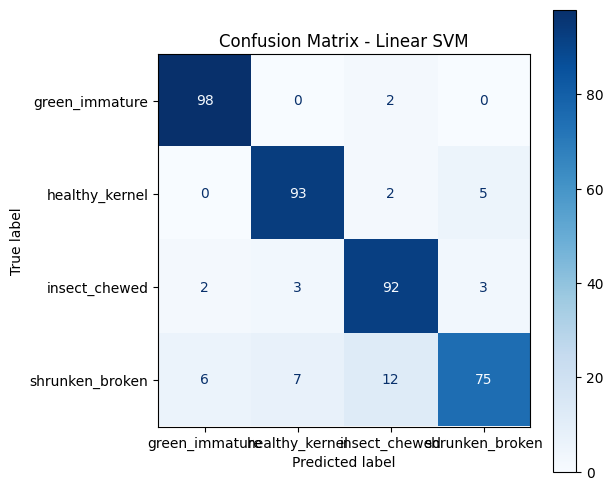

In [17]:
y_pred = clf_LinearSVC.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nDetailed Classification Report with LinearSVC:")
print("="*60)
print(classification_report(y_test, y_pred))
print("="*60)
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay.from_estimator(clf_LinearSVC, X_test_scaled, y_test, cmap="Blues", ax=ax)
plt.title("Confusion Matrix - Linear SVM")
plt.show()

### 16. Pengujian Skenario Kombinasi Fitur (5-Fold Cross Validation pada Data Training)
Membandingkan performa model pada 4 skenario kombinasi fitur berbeda (GLCM saja, warna saja, gabungan, dan gabungan tanpa normalisasi) menggunakan 5-fold Stratified Cross Validation **hanya pada `X_train`/`y_train`** — sama seperti cell CV model utama — agar `X_test` tetap murni tidak tersentuh sampai evaluasi akhir.

In [18]:
skf_scenarios = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scenarios = {
    'S1 — GLCM saja': ['contrast_0', 'dissimilarity_0', 'homogeneity_0', 'energy_0', 'correlation_0'],
    'S2 — Warna saja': ['mean_g', 'std_g', 'mean_v', 'std_v'],
    'S3 — GLCM + Warna (gabungan)': ['contrast_0', 'dissimilarity_0', 'homogeneity_0', 'energy_0',
                                      'correlation_0', 'mean_g', 'std_g', 'mean_v', 'std_v'],
    'S4 — Gabungan tanpa normalisasi': ['contrast_0', 'dissimilarity_0', 'homogeneity_0', 'energy_0',
                                         'correlation_0', 'mean_g', 'std_g', 'mean_v', 'std_v'],
}

results = []

for name, feat_cols in scenarios.items():
    X_sc = X_train[feat_cols]
    y_sc = y_train

    if 'tanpa normalisasi' in name:
        model_sc = LinearSVC(random_state=42, max_iter=2000)
    else:
        model_sc = Pipeline([
            ('scaler', StandardScaler()),
            ('svm', LinearSVC(random_state=42, max_iter=2000))
        ])

    cv_scores_sc = cross_val_score(model_sc, X_sc, y_sc, cv=skf_scenarios, scoring='accuracy')
    y_pred_cv = cross_val_predict(model_sc, X_sc, y_sc, cv=skf_scenarios)

    results.append({
        'Skenario': name,
        'Jumlah Fitur': len(feat_cols),
        'Mean Akurasi': f'{cv_scores_sc.mean()*100:.2f}%',
        'Std': f'{cv_scores_sc.std()*100:.2f}%',
    })

    print(f'\n{"="*55}')
    print(f'{name}')
    print(f'Akurasi per fold: {[f"{s*100:.2f}%" for s in cv_scores_sc]}')
    print(f'Mean Akurasi: {cv_scores_sc.mean()*100:.2f}% (± {cv_scores_sc.std()*100:.2f}%)')
    print(classification_report(y_sc, y_pred_cv))

print('\n' + '='*55)
print('RINGKASAN HASIL SKEMA PENGUJIAN (5-Fold CV pada Data Training)')
print('='*55)
for r in results:
    print(f"{r['Skenario']:<40} | {r['Jumlah Fitur']} fitur | {r['Mean Akurasi']} (± {r['Std']})")

C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` expli


S1 — GLCM saja
Akurasi per fold: ['79.06%', '76.25%', '74.06%', '73.12%', '74.69%']
Mean Akurasi: 75.44% (± 2.08%)
                 precision    recall  f1-score   support

 green_immature       0.80      0.81      0.81       400
 healthy_kernel       0.81      0.91      0.86       400
  insect_chewed       0.73      0.75      0.74       400
shrunken_broken       0.66      0.54      0.59       400

       accuracy                           0.75      1600
      macro avg       0.75      0.75      0.75      1600
   weighted avg       0.75      0.75      0.75      1600



C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` expli


S2 — Warna saja
Akurasi per fold: ['82.50%', '83.44%', '82.19%', '80.94%', '84.06%']
Mean Akurasi: 82.62% (± 1.08%)
                 precision    recall  f1-score   support

 green_immature       0.94      0.94      0.94       400
 healthy_kernel       0.85      0.93      0.89       400
  insect_chewed       0.76      0.84      0.80       400
shrunken_broken       0.74      0.59      0.66       400

       accuracy                           0.83      1600
      macro avg       0.82      0.83      0.82      1600
   weighted avg       0.82      0.83      0.82      1600



C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` expli


S3 — GLCM + Warna (gabungan)
Akurasi per fold: ['87.81%', '89.38%', '87.19%', '84.69%', '86.88%']
Mean Akurasi: 87.19% (± 1.52%)
                 precision    recall  f1-score   support

 green_immature       0.94      0.96      0.95       400
 healthy_kernel       0.91      0.94      0.92       400
  insect_chewed       0.79      0.90      0.84       400
shrunken_broken       0.86      0.69      0.76       400

       accuracy                           0.87      1600
      macro avg       0.87      0.87      0.87      1600
   weighted avg       0.87      0.87      0.87      1600



C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\


S4 — Gabungan tanpa normalisasi
Akurasi per fold: ['66.56%', '78.12%', '64.38%', '79.69%', '75.62%']
Mean Akurasi: 72.88% (± 6.22%)
                 precision    recall  f1-score   support

 green_immature       0.99      0.90      0.94       400
 healthy_kernel       0.76      0.94      0.84       400
  insect_chewed       0.59      0.79      0.67       400
shrunken_broken       0.56      0.28      0.38       400

       accuracy                           0.73      1600
      macro avg       0.72      0.73      0.71      1600
   weighted avg       0.72      0.73      0.71      1600


RINGKASAN HASIL SKEMA PENGUJIAN (5-Fold CV pada Data Training)
S1 — GLCM saja                           | 5 fitur | 75.44% (± 2.08%)
S2 — Warna saja                          | 4 fitur | 82.62% (± 1.08%)
S3 — GLCM + Warna (gabungan)             | 9 fitur | 87.19% (± 1.52%)
S4 — Gabungan tanpa normalisasi          | 9 fitur | 72.88% (± 6.22%)


C:\Users\Ilham Fahrezy\AppData\Roaming\Python\Python310\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Versi Library

In [19]:
import cv2, skimage, numpy, pandas, sklearn, matplotlib
print("Python      :", __import__('sys').version)
print("OpenCV      :", cv2.__version__)
print("scikit-image:", skimage.__version__)
print("NumPy       :", numpy.__version__)
print("Pandas      :", pandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("Matplotlib  :", matplotlib.__version__)

Python      : 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
OpenCV      : 4.10.0
scikit-image: 0.23.2
NumPy       : 1.26.4
Pandas      : 2.2.2
scikit-learn: 1.4.2
Matplotlib  : 3.9.0
